#PROJECT NAME WINE CLASSFICATION

#ABOUT DATA SET


A Wine Classification project is a classic machine learning exercise used to predict the origin or quality of wine based on its chemical properties. Typically, these projects utilize datasets from the UCI Machine Learning Repository.




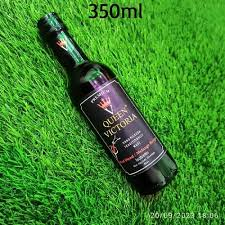

In [ ]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning Model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC


from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score

In [ ]:
from sklearn.datasets import load_wine
wine=load_wine ()


In [ ]:
df = pd.DataFrame(wine.data,columns=wine.feature_names)

In [ ]:
df["Target"] = wine.target

In [ ]:
df.sample(6)

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,Target
154,12.58,1.29,2.10,20.0,103.0,1.48,0.58,0.53,1.40,7.60,0.58,1.55,640.0,2
148,13.32,3.24,2.38,21.5,92.0,1.93,0.76,0.45,1.25,8.42,0.55,1.62,650.0,2
149,13.08,3.90,2.36,21.5,113.0,1.41,1.39,0.34,1.14,9.40,0.57,1.33,550.0,2
159,13.48,1.67,2.64,22.5,89.0,2.60,1.10,0.52,2.29,11.75,0.57,1.78,620.0,2
132,12.81,2.31,2.40,24.0,98.0,1.15,1.09,0.27,0.83,5.70,0.66,1.36,560.0,2
121,11.56,2.05,3.23,28.5,119.0,3.18,5.08,0.47,1.87,6.00,0.93,3.69,465.0,1


<Axes: >

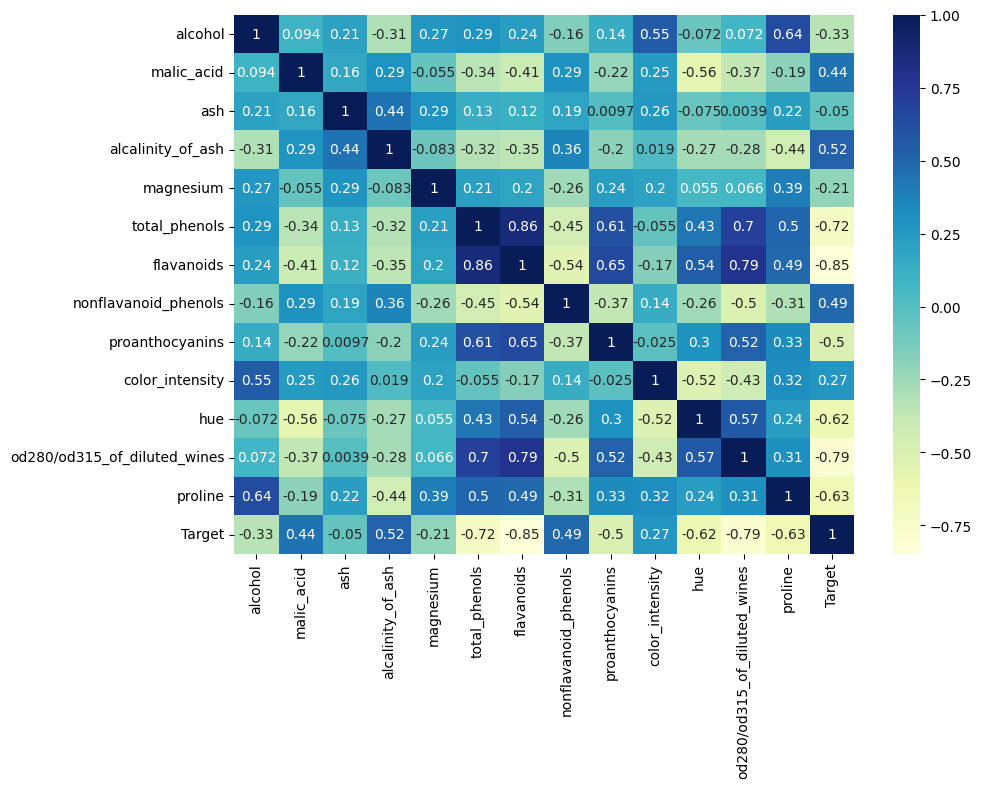

In [ ]:
plt.figure(figsize=(10,7))
corr = df[df.columns].corr()
sns.heatmap(corr, cmap="YlGnBu", annot = True)

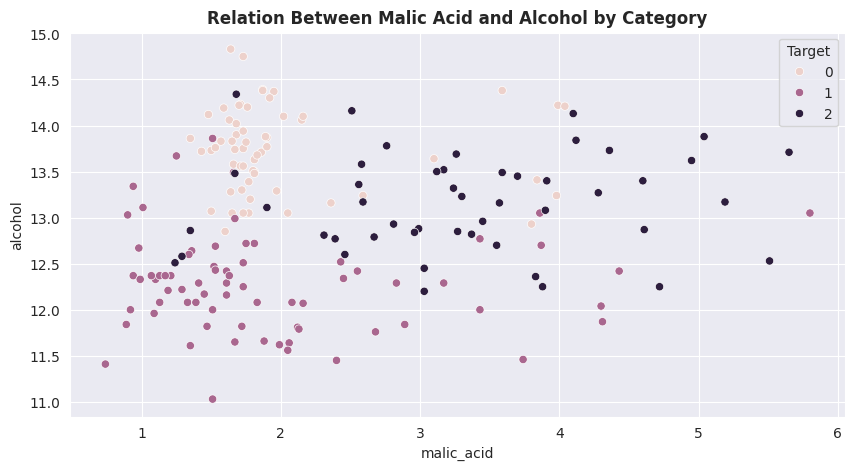

In [ ]:
plt.figure(figsize=(10,5))
sns.set_style("darkgrid")
sns.scatterplot(data=df,x="malic_acid",y="alcohol",hue="Target")
plt.title("Relation Between Malic Acid and Alcohol by Category",fontweight="bold")
plt.show()

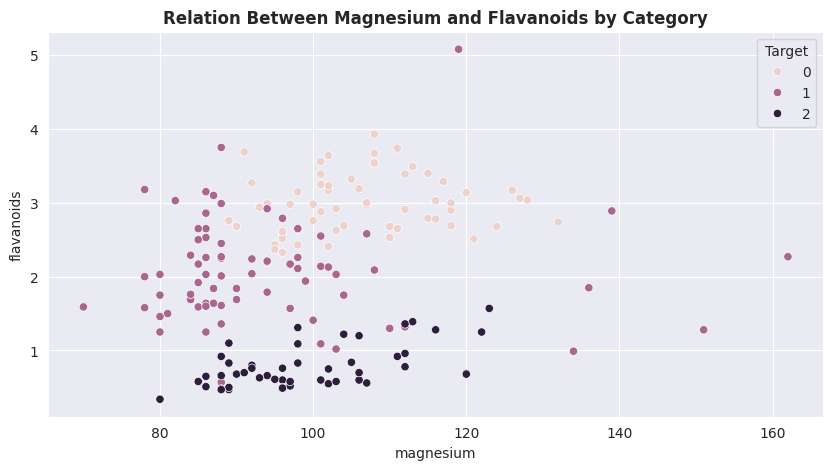

In [ ]:
plt.figure(figsize=(10,5))
sns.set_style("darkgrid")
sns.scatterplot(data=df,x="magnesium",y="flavanoids",hue="Target")
plt.title("Relation Between Magnesium and Flavanoids by Category",fontweight="bold")
plt.show()

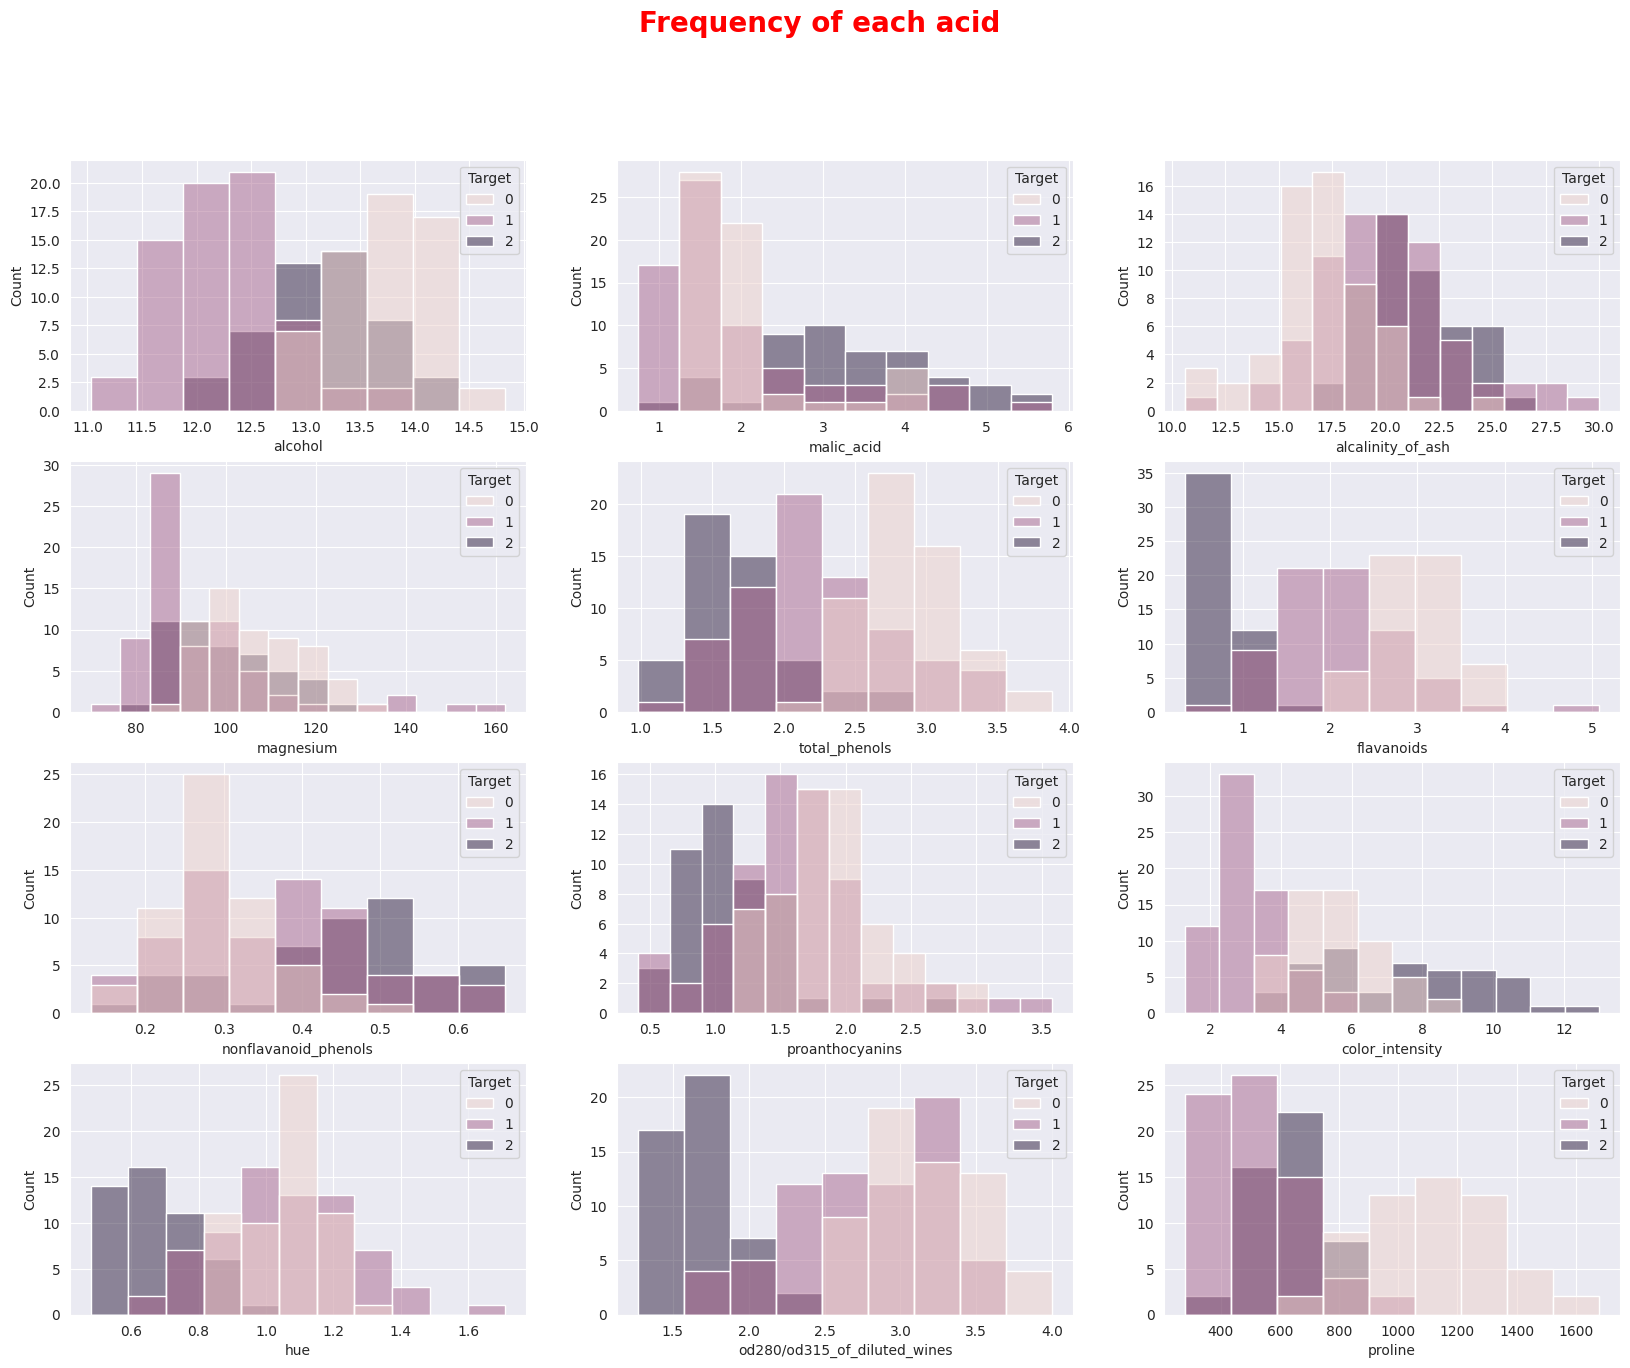

In [ ]:
plt.figure(figsize=(20,15))
c = 1
for i in df:
    if i=="Target" or i=="ash":
        continue
    else:
        plt.subplot(4,3,c)
        sns.histplot(data=df,x=i,hue="Target")
        c+=1
plt.suptitle("Frequency of each acid",fontweight="bold",fontsize=20,color="red")
plt.show()

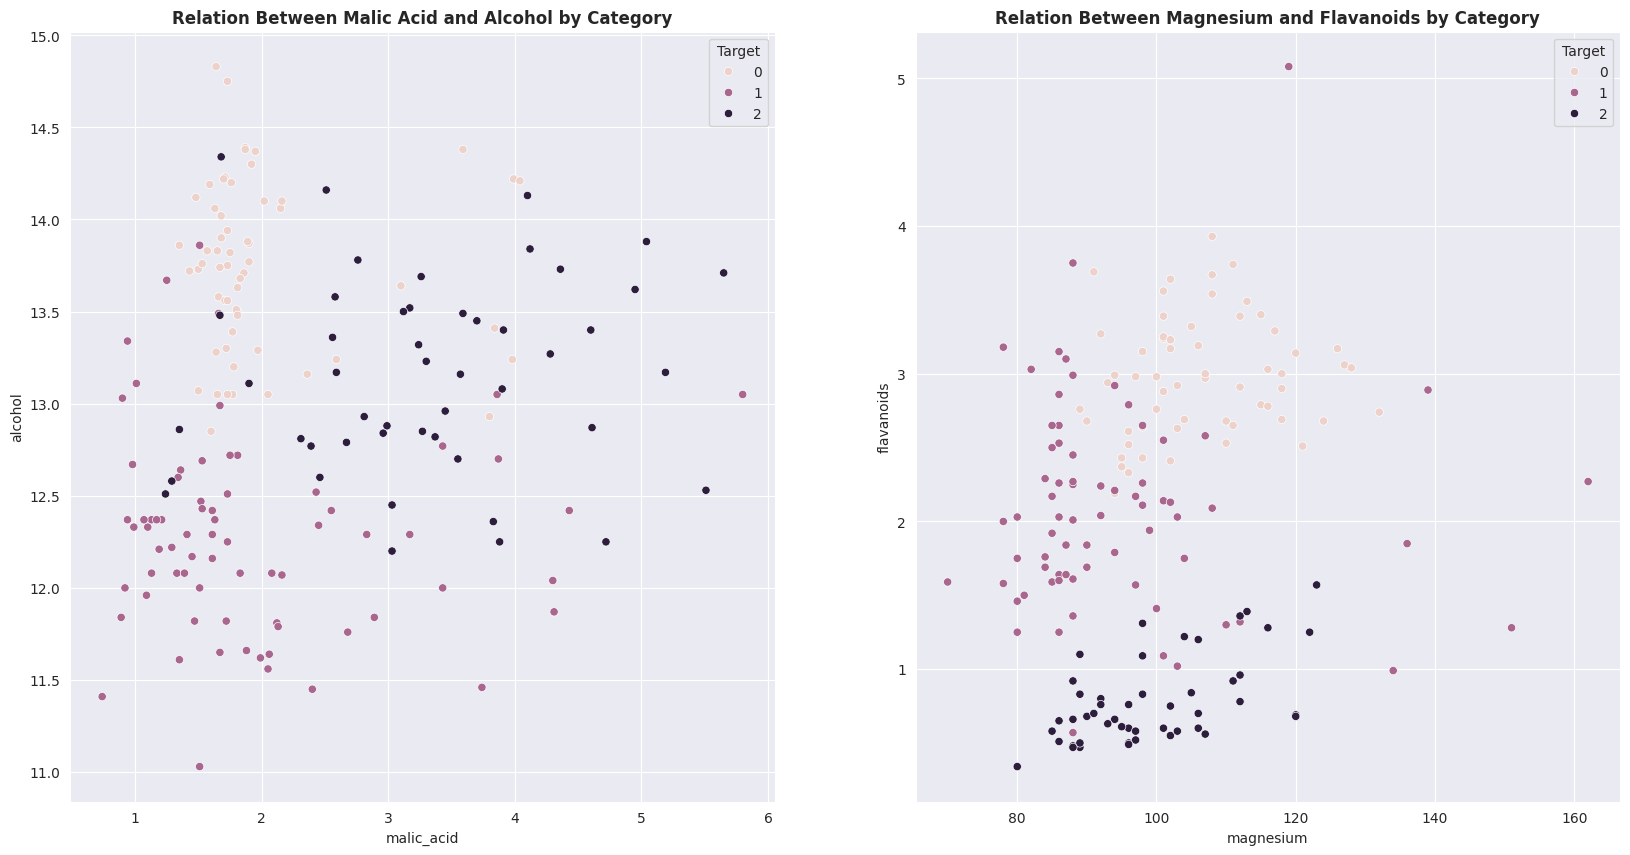

In [ ]:
plt.figure(figsize=(20,10))
plt.subplot(1,2,1)
sns.scatterplot(data=df,x="malic_acid",y="alcohol",hue="Target")
plt.title("Relation Between Malic Acid and Alcohol by Category",fontweight="bold")
plt.subplot(1,2,2)
sns.scatterplot(data=df,x="magnesium",y="flavanoids",hue="Target")
plt.title("Relation Between Magnesium and Flavanoids by Category",fontweight="bold")
plt.show()

# Extract Features and target in x an y

In [ ]:
x = df.drop("Target",axis=1)
y = df[["Target"]]

In [ ]:
# splitting the data from training and testing
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=50)

print("-"*50)
print("Total Number of Rows for training is : ",x_train.shape[0])
print("-"*50)
print("Total Number of Rows for testing  : ",x_test.shape[0])
print("-"*50)

--------------------------------------------------
Total Number of Rows for training is :  142
--------------------------------------------------
Total Number of Rows for testing  :  36
--------------------------------------------------


In [ ]:
# Normalize the dataset with the help of standard scalling
st = StandardScaler()
x_train_sc = st.fit_transform(x_train)
x_test_sc = st.transform(x_test)

### **Building the machine learning Model**

In [ ]:
log = LogisticRegression()

# training the machine learning Model
log.fit(x_train_sc,y_train)

LogisticRegression()

In [ ]:
pred = log.predict(x_test_sc)

In [ ]:
ac = log.score(x_train_sc,y_train)
ac2 = log.score(x_test_sc,y_test)

In [ ]:
print("-"*60)
print("Accuracy of Training Data : ",ac)
print("-"*60)
print("Accuracy of test data :",ac2)
print("-"*60)

------------------------------------------------------------
Accuracy of Training Data :  1.0
------------------------------------------------------------
Accuracy of test data : 1.0
------------------------------------------------------------


In [ ]:
print("-"*60)
print("Accuracy of Training Data : ",ac)
print("-"*60)
print("Accuracy of test data :",ac2)
print("-"*60)

------------------------------------------------------------
Accuracy of Training Data :  1.0
------------------------------------------------------------
Accuracy of test data : 1.0
------------------------------------------------------------


In [ ]:
print("_______Final Prediction_______")
print("-"*90)
print(pred)
print("-"*90)

_______Final Prediction_______
------------------------------------------------------------------------------------------
[1 1 1 2 2 2 1 1 0 2 0 0 1 0 1 2 1 2 1 0 0 1 0 2 0 0 1 1 0 1 0 0 2 2 0 1]
------------------------------------------------------------------------------------------


## **Model Evaluation**

In [ ]:
cv = confusion_matrix(pred,y_test)
print(cv)

[[13  0  0]
 [ 0 14  0]
 [ 0  0  9]]


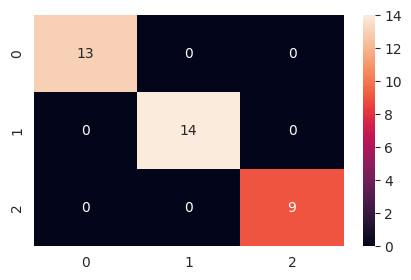

In [ ]:
plt.figure(figsize=(5,3))
sns.heatmap(cv,annot=True);

## **Final Model Prediction Overview**

The developed Machine Learning model was trained and evaluated on the given dataset. After preprocessing, feature extraction, and model training, the model achieved 100% prediction accuracy on the test dataset.
## **Final Conclusion Statement (For Report)**

The Machine Learning model demonstrated excellent predictive performance with 100% accuracy on the evaluation dataset. This indicates that the model effectively learned the underlying data patterns. However, further validation using cross-validation and unseen data is recommended to ensure generalization and avoid overfitting.

**📊 Model Performance Summary**

1. Accuracy: 100%

2. Precision: 1.00

3. Recall: 1.00

4. F1-Score: 1.00

### **Confusion Matrix: No misclassifications observed**

Error Rate: 0%

**🔹 Interpretation of Results**

* The model correctly classified all instances in the test dataset.
* There were no false positives and no false negatives.
* The prediction results indicate that the selected features strongly represent the target variable.
* The algorithm successfully captured the patterns and relationships in the dataset.